In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm
from scipy import optimize
import sympy

# Introduction to numerical methods

János Török

# Class 6: Error propagation and Root finding

## Fitting in python

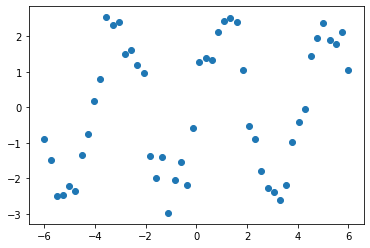

In [2]:
x_data = np.linspace(-6, 6, num=50)
y_data = 2.5 * np.sin(1.5 * x_data) + np.random.normal(size=50) / 2

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data)
plt.show()

In [3]:
def test_func(x, a, b):
    return a * np.sin(b * x)

params, params_covariance = optimize.curve_fit(test_func, x_data, y_data,
                                               p0=[2, 2])

print(params)
print(params_covariance)

[2.46717637 1.51189908]
[[6.83189050e-03 7.49660057e-05]
 [7.49660057e-05 9.51524262e-05]]


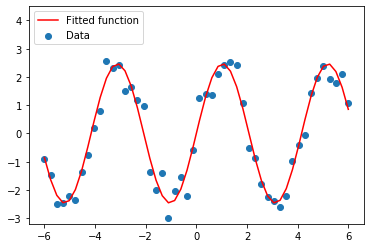

In [4]:
plt.figure()
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_data, test_func(x_data, params[0], params[1]),"r-",
         label='Fitted function')

plt.legend(loc='upper left')
axes = plt.gca()
axes.set_ylim([-3.2,4.5])
plt.show()

### Exponential and power law functions

Fit should be made to the logarithm!

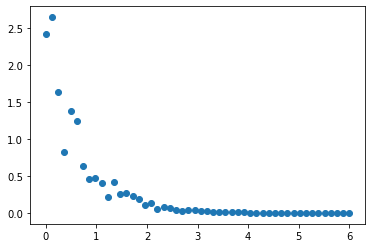

In [12]:
np.random.seed(12347)
x_data = np.linspace(0, 6, num=50)
y_data = 2.5 * np.exp(-1.5 * x_data) * (np.random.normal(size=50) * 0.2 + 0.9)

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data)
plt.show()

In [13]:
def test_exp(x, a, b):
    return a * np.exp(b * x)

expfit, params_covariance = optimize.curve_fit(test_exp, x_data, y_data,
                                               p0=[2, 2])

print(expfit)

[ 2.60687266 -1.67257391]


In [14]:
def test_lin(x, a, b):
    return a * x + b

linfit, params_covariance = optimize.curve_fit(test_lin, x_data, np.log(y_data),
                                               p0=[2, 2])

print(linfit[0],np.exp(linfit[1]))

-1.4872496011451897 2.2357494472694572


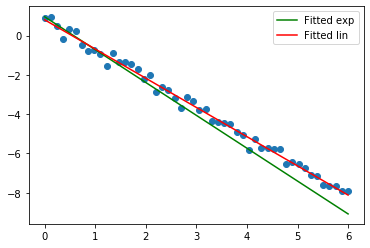

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(x_data, np.log(y_data))
plt.plot(x_data, np.log(test_exp(x_data, expfit[0], expfit[1])),
         label='Fitted exp',color="green")
plt.plot(x_data, test_lin(x_data, linfit[0], linfit[1]),
         label='Fitted lin',color="red")
plt.legend(loc='upper right')

plt.show()

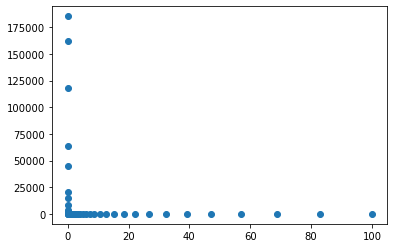

In [16]:
x_data = np.logspace(-2, 2, num=50)
y_data = 2.5 * x_data**(-2.5) * (np.random.normal(size=50) * 0.2 + 0.9)

# And plot it
plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data)
plt.show()

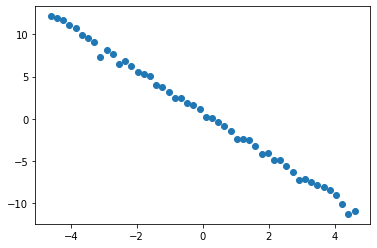

In [17]:
plt.figure(figsize=(6, 4))
plt.scatter(np.log(x_data), np.log(y_data))
plt.show()

Linear fit: -2.5128860628105754 2.049868755834559
Power law fit: -1.938743899030617 26.907540103847957


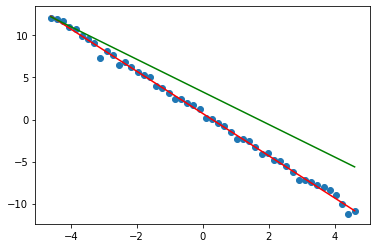

In [18]:
def test_lin(x, a, b):
    return a * x + b
def test_power(x, a, b):
    return b * x**a

linfit, params_covariance = optimize.curve_fit(test_lin, np.log(x_data), np.log(y_data),
                                               p0=[2, 2])
powfit, params_covariance = optimize.curve_fit(test_power, x_data, y_data,
                                               p0=[-2.5, 2])
print("Linear fit:", linfit[0],np.exp(linfit[1]))
print("Power law fit:",powfit[0],powfit[1])
plt.figure(figsize=(6, 4))
plt.scatter(np.log(x_data), np.log(y_data))
plt.plot(np.log(x_data),test_lin(np.log(x_data),linfit[0],linfit[1]),'r-')
plt.plot(np.log(x_data),test_lin(np.log(x_data),powfit[0],np.log(powfit[1])),'g-')
plt.show()

# Error propagation
Source of errors in data:
 * Precision of instrument
 * Human error
 * Stochastic nature of the data/phenomena
 * Environment
 * etc.

Error types:
 * Random
   * Always repeat experiment if possible, to reduce random error (see below)
 * Systematic
   * Repeat the measurent in different environments which may cancel out the systematic error. Vary parameters which may show the direction and magnitutde of the error
   * In general systematic error sucks


## Random errors
Random errors are supposed to have a Normal distribution with a muean $\mu$ and a standard deviation of $\sigma$. If the data reads as $x_1,~x_2,\dots,x_n$, then these quantities are calculated as:
$$
\begin{align*}
\bar x &= \frac{1}{n}\sum_{i=1}^n x_i\cr
\sigma &= \sqrt{\frac{1}{n}\sum_{i=1}^n(x_i-\bar x)^2}
\end{align*}
$$
For sample standard deviation it is costumary to use $n-1$ in the denominators to correct for the downward bias introduced by the concavity of the square root function.
$$
s_x = \sqrt{\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2}
$$

#### Some customary definitions: 

 * Often we are interested in the <b>standard deviation of the mean</b>:
$$
\sigma_{\bar x}=\sqrt{\frac{1}{n(n-1)}\sum_{i=1}^n(x_i-\bar x)^2}$$
This also indicates that if we measure $n$ data points then the standard deviation of the mean is reduced by $\sqrt{n}$
 * <b>$68$% confidence interval</b>: $\bar x \pm \sigma_{\bar x}$
 * <b>$95$% confidence interval</b>: $\bar x \pm 2\sigma_{\bar x}$
 * <b>$99.7$% confidence interval</b>: $\bar x \pm 3\sigma_{\bar x}$
 * A confidence interval of the mean is a measure of the uncertainty in the estimate of the mean and is generally denoted as $\bar x \pm \Delta x$

The question we would like to answer here is what happens with the variances of different quantities if we apply some arithmetic operations to them.

#### Two variable operations
Any non-linear differentiable function, $f(a,b)$, of two variables, $a$ and $b$, can be expanded as
$$f\approx f^0+\frac{\partial f}{\partial a}a+\frac{\partial f}{\partial b}b.$$
If we take the variance on both sides and use the formula for the variance of a linear combination of variables
$$\operatorname{Var}(aX + bY) = a^2\operatorname{Var}(X) + b^2\operatorname{Var}(Y) + 2ab \operatorname{Cov}(X, Y),$$
then we obtain
$$\sigma^2_f\approx\left| \frac{\partial f}{\partial a}\right| ^2\sigma^2_a+\left| \frac{\partial f}{\partial b}\right|^2\sigma^2_b+2\frac{\partial f}{\partial a}\frac{\partial f} {\partial b}\sigma_{ab},$$
where $\sigma_{f}$ is the standard deviation of the function $f$, $\sigma_{a}$ is the standard deviation of $a$, $\sigma_{b}$ is the standard deviation of $b$ and $\sigma_{ab} = \sigma_{a}\sigma_{b} \rho_{ab}$ is the covariance between $a$ and $b$. If $a$ and $b$ are uncorrelated then $\sigma_{ab}\equiv 0$.

#### Functions
(Only for independent variables)
 * <b>Multipliation by a constant</b>: $f(a)=Ca$: $\sigma_f=|C|\sigma_a$
 * <b>Addition/subtraction:</b> $f(a,b)=a\pm b$: In this case all the derivates are $\pm1$ which translates to $\sigma_f=\sqrt{\sigma_a^2+\sigma_b^2}$. Please note that this translates to the $1/\sqrt{n}$ factor for $n$ independent measurements (the $1/n$ comes from the average).
 * <b>Product/division:</b> $f(a,b)=ab$: $$\sigma_f=|f|\sqrt{\left(\frac{\sigma_a^2}{a}\right)^2+\left(\frac{\sigma_a^2}{b}\right)^2}$$
 * <b>Exponentiation:</b> $f(a)=a^\gamma$: $\sigma_f = |f\gamma \sigma_a/a|$

In [19]:
a = np.random.normal(2,1,100000)
b = np.random.normal(-4,3,100000)

In [20]:
def hist(x,bins=20):
    xmin = x.min()
    xmax = x.max()
    bins = np.linspace(xmin,xmax,bins)
    h,b = np.histogram(x,bins = bins,density=True)
    xpos = (bins[1:]+bins[:-1])/2
    return h,xpos

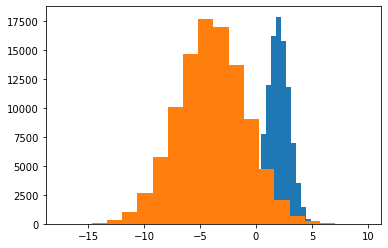

In [24]:

plt.hist(a,bins=20);
plt.hist(b,bins=20);

In [25]:
norm.fit(a),norm.fit(b)

((2.000785331891081, 1.0017213078287768),
 (-3.9756609684279827, 3.0052774993874545))

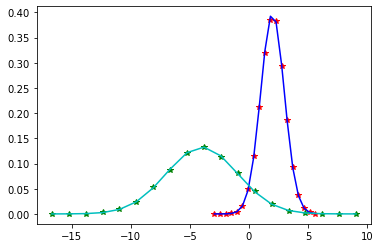

In [26]:
h,x = hist(a)
mua,sa = norm.fit(a)
plt.plot(x,h,"r*");
plt.plot(x,norm.pdf(x, mua, sa),"b-")
h,x = hist(b)
mub,sb = norm.fit(b)
plt.plot(x,h,"g*");
plt.plot(x,norm.pdf(x, mub, sb),"c-")

Measured: -1.9748756365369027 3.170421098201011
Calculated: -1.9748756365369018 3.1678286612256517


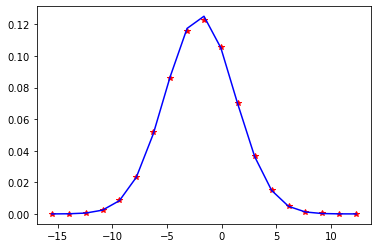

In [27]:
h,x = hist(a+b)
plt.plot(x,h,"r*");
plt.plot(x,norm.pdf(x, mua+mub, np.sqrt(sa**2+sb**2)),"b-")
muab,sab = norm.fit(a+b)
print("Measured:",muab,sab)
print("Calculated:",mua+mub, np.sqrt(sa**2+sb**2))

Measured: 5.976446300319063 3.1652341009548266
Calculated: 5.976446300319063 3.1678286612256517


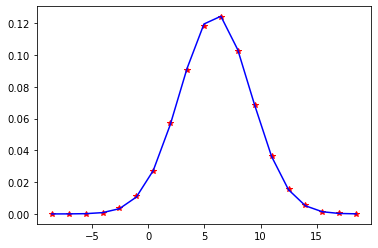

In [28]:
h,x = hist(a-b)
plt.plot(x,h,"r*");
plt.plot(x,norm.pdf(x, mua-mub, np.sqrt(sa**2+sb**2)),"b-")
muab,sab = norm.fit(a-b)
print("Measured:",muab,sab)
print("Calculated:",mua-mub, np.sqrt(sa**2+sb**2))

Measured: -7.946228393684898 7.796345311112365
Calculated: -7.9544441502025975 7.212176440356155


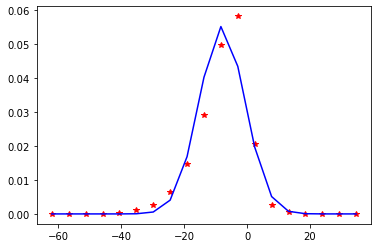

In [29]:
h,x = hist(a*b)
plt.plot(x,h,"r*");
plt.plot(x,norm.pdf(x, mua*mub, np.abs(mua*mub)*np.sqrt((sa/mua)**2+(sb/mub)**2)),"b-")
muab,sab = norm.fit(a*b)
print("Measured:",muab,sab)
print("Calculated:",mua*mub, np.abs(mua*mub)*np.sqrt((sa/mua)**2+(sb/mub)**2))

# Root finding
The basic problem we want to solve here is
$$f(x)=0.$$
The same problem can be set in any dimensions:
$$\begin{align*}
f_1(x_1,x_2,\dots,x_{n}) &=0\cr
f_2(x_1,x_2,\dots,x_{n}) &=0\cr
 &\vdots\cr
f_n(x_1,x_2,\dots,x_{n}) &=0
\end{align*}$$

## Fixed point method
In some cases the iteration of the following equation converges:
$$x=g(x)$$
It is easy to convert the above problem to  a fixed point one:
$$g(x)=f(x)+x.$$

The process works as depicted in the following figure:

<img src="class08/fixpoint.png" width="400px">

There are two type of fixed points: 
Stable and unstable. In stable ones the derivative of $f(x)$ is smaller than 1 so the iteration converges to the fixed point.
Two tricks:
 1. Multiply $f(x)$ with a small number
 2. Multiply $f(x)$ with a negative number to get the fixed points when $f(x)$ crosses $y=x$ from below

Some examples:

In [30]:
def f1(x):
    return np.exp(x-np.sqrt(x))-x

<ipython-input-30-2ddf038f9a29>:2: RuntimeWarning:

invalid value encountered in sqrt



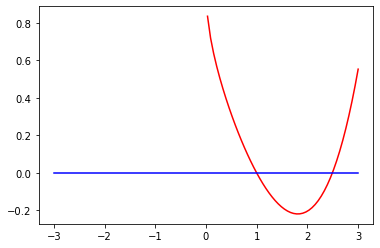

In [31]:
x = np.linspace(-3,3,100)
plt.plot(x,f1(x),"r-")
plt.plot(x,x*0,"b-")

In [32]:
def f2(x):
    return np.sin(x*2*np.pi)+x*x

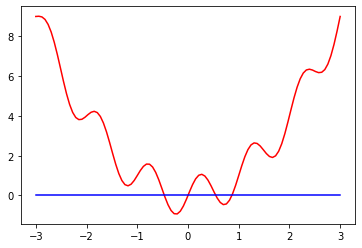

In [33]:
x = np.linspace(-3,3,100)
plt.plot(x,f2(x),"r-")
plt.plot(x,x*0,"b-")

In [34]:
def recursion(f,m,x0,niter):
    for i in range(niter):
        x0 = f(x0)/m + x0
    return(x0)

In [35]:
xi = np.zeros_like(x)
for i,x0 in enumerate(x):
    xi[i] = recursion(f1,1,x0,2)

<ipython-input-30-2ddf038f9a29>:2: RuntimeWarning:

invalid value encountered in sqrt



<ipython-input-30-2ddf038f9a29>:2: RuntimeWarning:

invalid value encountered in sqrt



(0, 6)

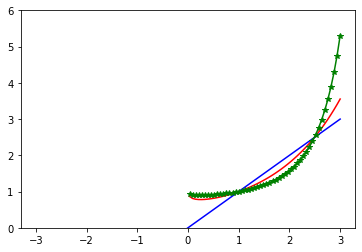

In [36]:
plt.plot(x,f1(x)+x,"r-")
plt.plot(x,x,"b-")
plt.plot(x,xi,"g*-")
plt.ylim(0,6)

In [37]:
xi = np.zeros_like(x)
for i,x0 in enumerate(x):
    xi[i] = recursion(f1,-1,x0,2)

<ipython-input-30-2ddf038f9a29>:2: RuntimeWarning:

invalid value encountered in sqrt



<ipython-input-30-2ddf038f9a29>:2: RuntimeWarning:

invalid value encountered in sqrt



(0, 6)

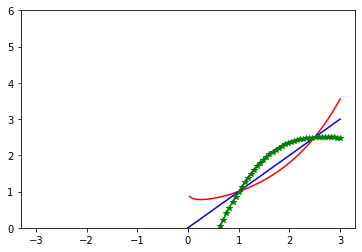

In [38]:
plt.plot(x,f1(x)+x,"r-")
plt.plot(x,x,"b-")
plt.plot(x,xi,"g*-")
plt.ylim(0,6)

In [39]:
x = np.linspace(-3,3,300)
xi = np.zeros_like(x)
for i,x0 in enumerate(x):
    xi[i] = recursion(f2,10,x0,20)

<ipython-input-32-0993a05cc4d8>:2: RuntimeWarning:

overflow encountered in double_scalars

<ipython-input-32-0993a05cc4d8>:2: RuntimeWarning:

invalid value encountered in sin



(-2, 6)

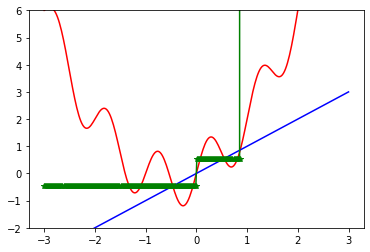

In [40]:
plt.plot(x,f2(x)+x,"r-")
plt.plot(x,x,"b-")
plt.plot(x,xi,"g*-")
plt.ylim(-2,6)

In [41]:
x = np.linspace(-3,3,300)
xi = np.zeros_like(x)
for i,x0 in enumerate(x):
    xi[i] = recursion(f2,-10,x0,20)

<ipython-input-32-0993a05cc4d8>:2: RuntimeWarning:

overflow encountered in double_scalars

<ipython-input-32-0993a05cc4d8>:2: RuntimeWarning:

invalid value encountered in sin



(-2, 6)

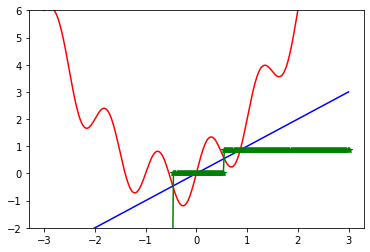

In [42]:
plt.plot(x,f2(x)+x,"r-")
plt.plot(x,x,"b-")
plt.plot(x,xi,"g*-")
plt.ylim(-2,6)

### Conclusion from the fixed point method

It is easy to implement and understand, but has two major drawbacks:
 1. The multiplication values must be checked against the derivatives it can be expensive or arbitrary
 2. It is difficult to control where to start the iteration

## Bisection method
The idea is simple start with an interval $[x_1,x_2]$ such that the sign of $f(x)$ is different at the two endpoints: 
$$\mathrm{sgn}(f(x_1))\cdot \mathrm{sgn}(f(x_2)) < 0.$$
We bisect the interval $x_0=(x_1+x_2)/2$ and check the sign of $f(x_0)$. We set $x_1$ or $x_2$ to $x_0$ in such a way that the new interval still satisfies: $\mathrm{sgn}(f(x_1))\cdot \mathrm{sgn}(f(x_2)) < 0.$

In [43]:
def bisection(f,x1,x2,tol = 1e-5):
    if f(x1) * f(x2) >= 0:
        return np.nan
    while np.abs(x1-x2) > tol:
        x0 = (x1+x2)/2
        if f(x0)*f(x1) >= 0:
            x1 = x0
        else:
            x2 = x0
    return(x0)

In [44]:
bisection(f2,-0.3,3)

2.861022949233259e-06

In [45]:
bisection(f2,-0.3,2)

0.8653278350830078

In [46]:
bisection(f2,-1,-0.3)

-0.4652748107910156

In [48]:
x = np.linspace(-3,3,300)
xi = np.zeros_like(x)
for i,x0 in enumerate(x):
    xi[i] = bisection(f2,x0,3.1)

(-2, 6)

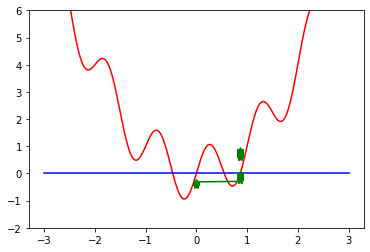

In [57]:
plt.plot(x,f2(x),"r-")
plt.plot(x,x*0,"b-")
plt.plot(xi,x,"g*-")
plt.ylim(-2,6)